<a href="https://colab.research.google.com/github/A-Chern0v/PINN_example/blob/main/PINN(theory%2Bpractice).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Что такое PINN?
---

PINN - это тип нейронной сети, который использует **не только данные, но и физические законы**, чтобы обучаться и делать предсказания.

Обычные нейросети (например, для распознавания изображений или прогнозирования цен) учатся только на данных:  
*-> вход - данные -> выход - ответ -> минимизация ошибки между предсказанием и реальностью.*

PINN идёт дальше: она знает, что **данные должны подчиняться уравнениям физики** - например, законам сохранения, дифференциальным уравнениям и т.д.

## Принцип работы

В основе PINN заложена следующая идея:  
"Если я обучаю нейросеть, то я не просто хочу, чтобы она подгоняла данные, я хочу, чтобы её предсказания соблюдали физические условия."

Например, если у нас есть процесс, описываемый **дифференциальным уравнением**:
$$\frac{du}{dt} = f(u,t),$$
то мы можем сделать так, чтобы нейросеть **сама училась решать это уравнение,**
даже если у нас мало реальных данных.

## Как это делается технически

Обучение PINN включает две части:
1. **Ошибка по данным (Data loss)** - обычная ошибка между предсказаниями сети и известными экспериментальными данными.
2. **Ошибка по физике (Physics loss)** - ошибка между тем, что предсказывает сеть, и тем, что **должно быть** согласно физическому уравнению.

Общая функция потерь выглядит следующим образом:
$$Loss = {Loss}_{data} + {Loss}_{physics}$$

Таким образом, сеть **подгоняется и под данные, и под физику** одновременно.

## Пример: колебания маятника

Предположим, у нас есть маятник, описываемый уравнением:

$$\frac{d^2\theta}{dt^2} + \frac{g}{L}\sin({\theta}) = 0$$

Мы хотим предсказывать положение маятника во времени, но у нас мало измерений.

### Шаги:

1. Создаём нейросеть, которая принимает $t$ (время) и выдает $\theta$ (угол отклонения).
2. С помощью автодифференцирования считаем производные $\frac{d\theta}{dt}$ и $\frac{d^2\theta}{dt^2} .$
3. Добавляем в loss-функцию условие, что:
$$\frac{d^2\theta}{dt^2} + \frac{g}{L}\sin({\theta}) \approx 0$$
  (то есть сеть должна соблюдать закон физики).
4. Плюс - добавляем немного реальных данных о положении маятника.

Сеть обучается и начинает предсказывать правильное движение маятника даже там, где у нас **нет данных** - потому что она **понимает физику** процесса.

## Пример из практики

PINN уже активно используются в:
* **Аэродинамике** - моделирование потоков жидкости вокруг самолётов без массивных CFD симуляций.
* **Механике твёрдого тела** - расчёт напряжений и деформаций.
* **Медицине** - моделирование кровотока.
* **Климотологии** - моделирование океанических и атмосферных процессов.

## Преимущества и недостатки

К преимуществам PINN можно отнести:
* Могут работать даже при **неполных данных**
* Гарантируют **физическую правдоподобность** результата
* Часто **обучаются быстрее**, чем численные симуляции
* Могут **обобщать** - т.е. работать в условиях, которые не видели.

К недостаткам PINN можно отнести:
* Могут быть сложными для настройки (особенно баланс между Loss-частями)
* Не всегда подходят для хаотических систем
* Требуют знаний физики, чтобы правильно задать уравнения

---
# Пример реализации PINN с помощью PyTorch
---

In [ ]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

## Мини-пример кода
Упрощённый пример PINN для решения уравнения $\frac{du}{dt} = -u :$

In [ ]:
# Сеть, предсказывающая u(t)
class PINN(nn.Module):

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32),
            nn.Tanh(),
            nn.Linear(32, 32),
            nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, t):
        return self.net(t)

In [ ]:
model = PINN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

for epoch in range(5000):
    t = torch.rand(100, 1)
    t.requires_grad_(True)
    u = model(t)
    du_dt = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]

    # Уравнение du/dt = -u
    physics_loss = ((du_dt + u)**2).mean()

    optimizer.zero_grad()
    physics_loss.backward()
    optimizer.step()

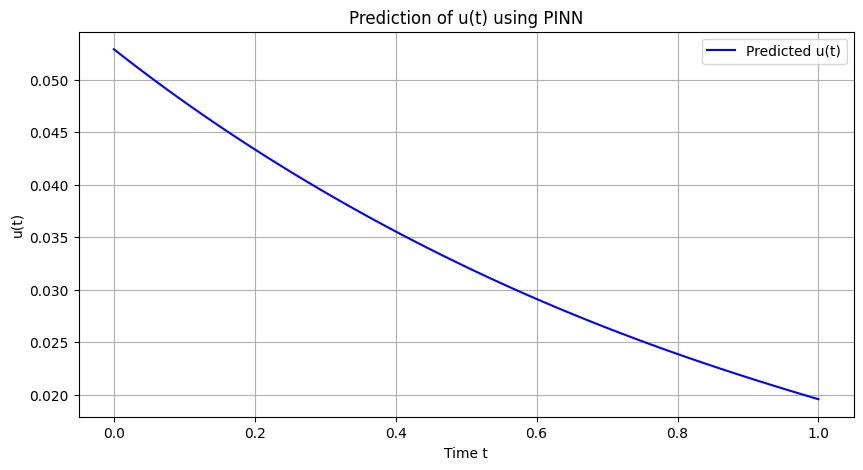

In [ ]:
# Вывод результатов

# Создаем временные точки для оценки модели
t_test = torch.linspace(0, 1, 100).view(-1, 1)
u_pred = model(t_test).detach().numpy() # Получаем предсказания и отключаем градиенты

# Визуализация результатов
plt.figure(figsize=(10, 5))
plt.plot(t_test.numpy(), u_pred, label='Predicted u(t)', color='blue')
plt.title('Prediction of u(t) using PINN')
plt.xlabel('Time t')
plt.ylabel('u(t)')
plt.legend()
plt.grid()
plt.show()

## Пример PINN, который решает уравнение теплопроводности (диффузии)

Простое уравнение теплопроводности выглядит следующим образом:

$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2} ,$$

где:
* $u(x,t)$ - температура в точке $x$ и момент времени $t ,$
* $\alpha$ - коэффициент теплопроводности.

Решим это уравнение **нейронной сетью PINN**, которая будет ***сама находить решение***, соблюдая физику.

### Постановка задачи

Предположим:
* отрезок $x \in [0, 1]$
* время $t \in [0, 1]$
* начальное условие: $u(x, 0) = sin(\pi x)$
* граничные условия: $u(0, t) = 0, \: u(1, t) = 0$
* коэффициент теплопроводности $\alpha = 0.1$

PINN-подход:
1. Создаём нейросеть, которая получает $(x, t)$ и выдаёт $u(x, t) .$
2. Считаем производные $u_t$ и $u_{xx}$ через автодифференцирование.
3. Loss-функция состоит из:
    * Сохранения физики: $u_t - \alpha u_{xx} = 0$
    * Начального условия $u(x, 0) = sin(\pi x)$
    * Граничных условий $u(0, t) = 0, \ u(1, t) = 0$

In [ ]:
# -------------------------
# 1. Настройки и параметры
# -------------------------

alpha = 0.1 # Коэффициент теплопроводности

# Устройство для вычислений
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ----------------------------------
# 2. Определяем нейронную сеть PINN
# ----------------------------------

class PINN(nn.Module):

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),   # вход: (x, t)
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 1)    # выход: u(x, t)
        )
    def forward(self, x, t):
        """Прямой проход: объединяем x и t в один тензор"""
        inputs = torch.cat([x, t], dim=1)
        return self.net(inputs)

# --------------------------------------
# 3. Функции для вычисления производных
# --------------------------------------

def derivatives(u, x, t):
    """Вычисляем u_t и u_xx через автодифференцирование"""

    # Первая производная по t
    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    # Первая производная по x
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    # Вторая производная по x
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]

    return u_t, u_xx

In [ ]:
# ---------------------------------------
# 4. Инициализация модели и оптимизатора
# ---------------------------------------

model = PINN().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [ ]:
# -----------------
# 5. Цикл обучения
# -----------------

for epoch in range(5000):

    # ---- Создаём обучающие точки ----
    # случайные точки в пространстве (x, t)
    x_f = torch.rand(1000, 1, requires_grad=True).to(device)
    t_f = torch.rand(1000, 1, requires_grad=True).to(device)

    # ---- Вычисляем предсказания ----
    u_pred = model(x_f, t_f)

    # ---- Считаем физическую ошибку (PDE) ----
    u_t, u_xx = derivatives(u_pred, x_f, t_f)
    physics_loss = ((u_t - alpha * u_xx) ** 2).mean()

    # ---- Начальные условия: u(x, 0) = sin(pi x) ----
    x0 = torch.rand(100, 1, requires_grad=True).to(device)
    t0 = torch.zeros_like(x0).to(device)
    u0_true = torch.sin(torch.pi * x0)
    u0_pred = model(x0, t0)
    ic_loss = ((u0_pred - u0_true) ** 2).mean()

    # ---- Граничные условия: u(0, t) = u(1, t) = 0 ----
    t_b = torch.rand(100, 1, requires_grad=True).to(device)
    x0_b = torch.zeros_like(t_b).to(device)
    x1_b = torch.ones_like(t_b).to(device)
    u_b0 = model(x0_b, t_b)
    u_b1 = model(x1_b, t_b)
    bc_loss = (u_b0 ** 2).mean() + (u_b1 ** 2).mean()

    # ---- Общая функция потерь ----
    loss = physics_loss + ic_loss + bc_loss

    # ---- Шаг оптимизации ----
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # ---- Вывод каждые 500 эпох ----
    if epoch % 500 == 0:
        print(f"Epoch {epoch}: Loss = {loss.item():.6f}")

/usr/local/lib/python3.12/dist-packages/torch/autograd/graph.py:829: UserWarning: Attempting to run cuBLAS, but there was no current CUDA context! Attempting to set the primary context... (Triggered internally at /pytorch/aten/src/ATen/cuda/CublasHandlePool.cpp:179.)
  return Variable._execution_engine.run_backward(  # Calls into the C++ engine to run the backward pass


Epoch 0: Loss = 0.468005
Epoch 500: Loss = 0.002283
Epoch 1000: Loss = 0.001000
Epoch 1500: Loss = 0.000449
Epoch 2000: Loss = 0.000129
Epoch 2500: Loss = 0.000097
Epoch 3000: Loss = 0.000062
Epoch 3500: Loss = 0.000957
Epoch 4000: Loss = 0.000098
Epoch 4500: Loss = 0.000029


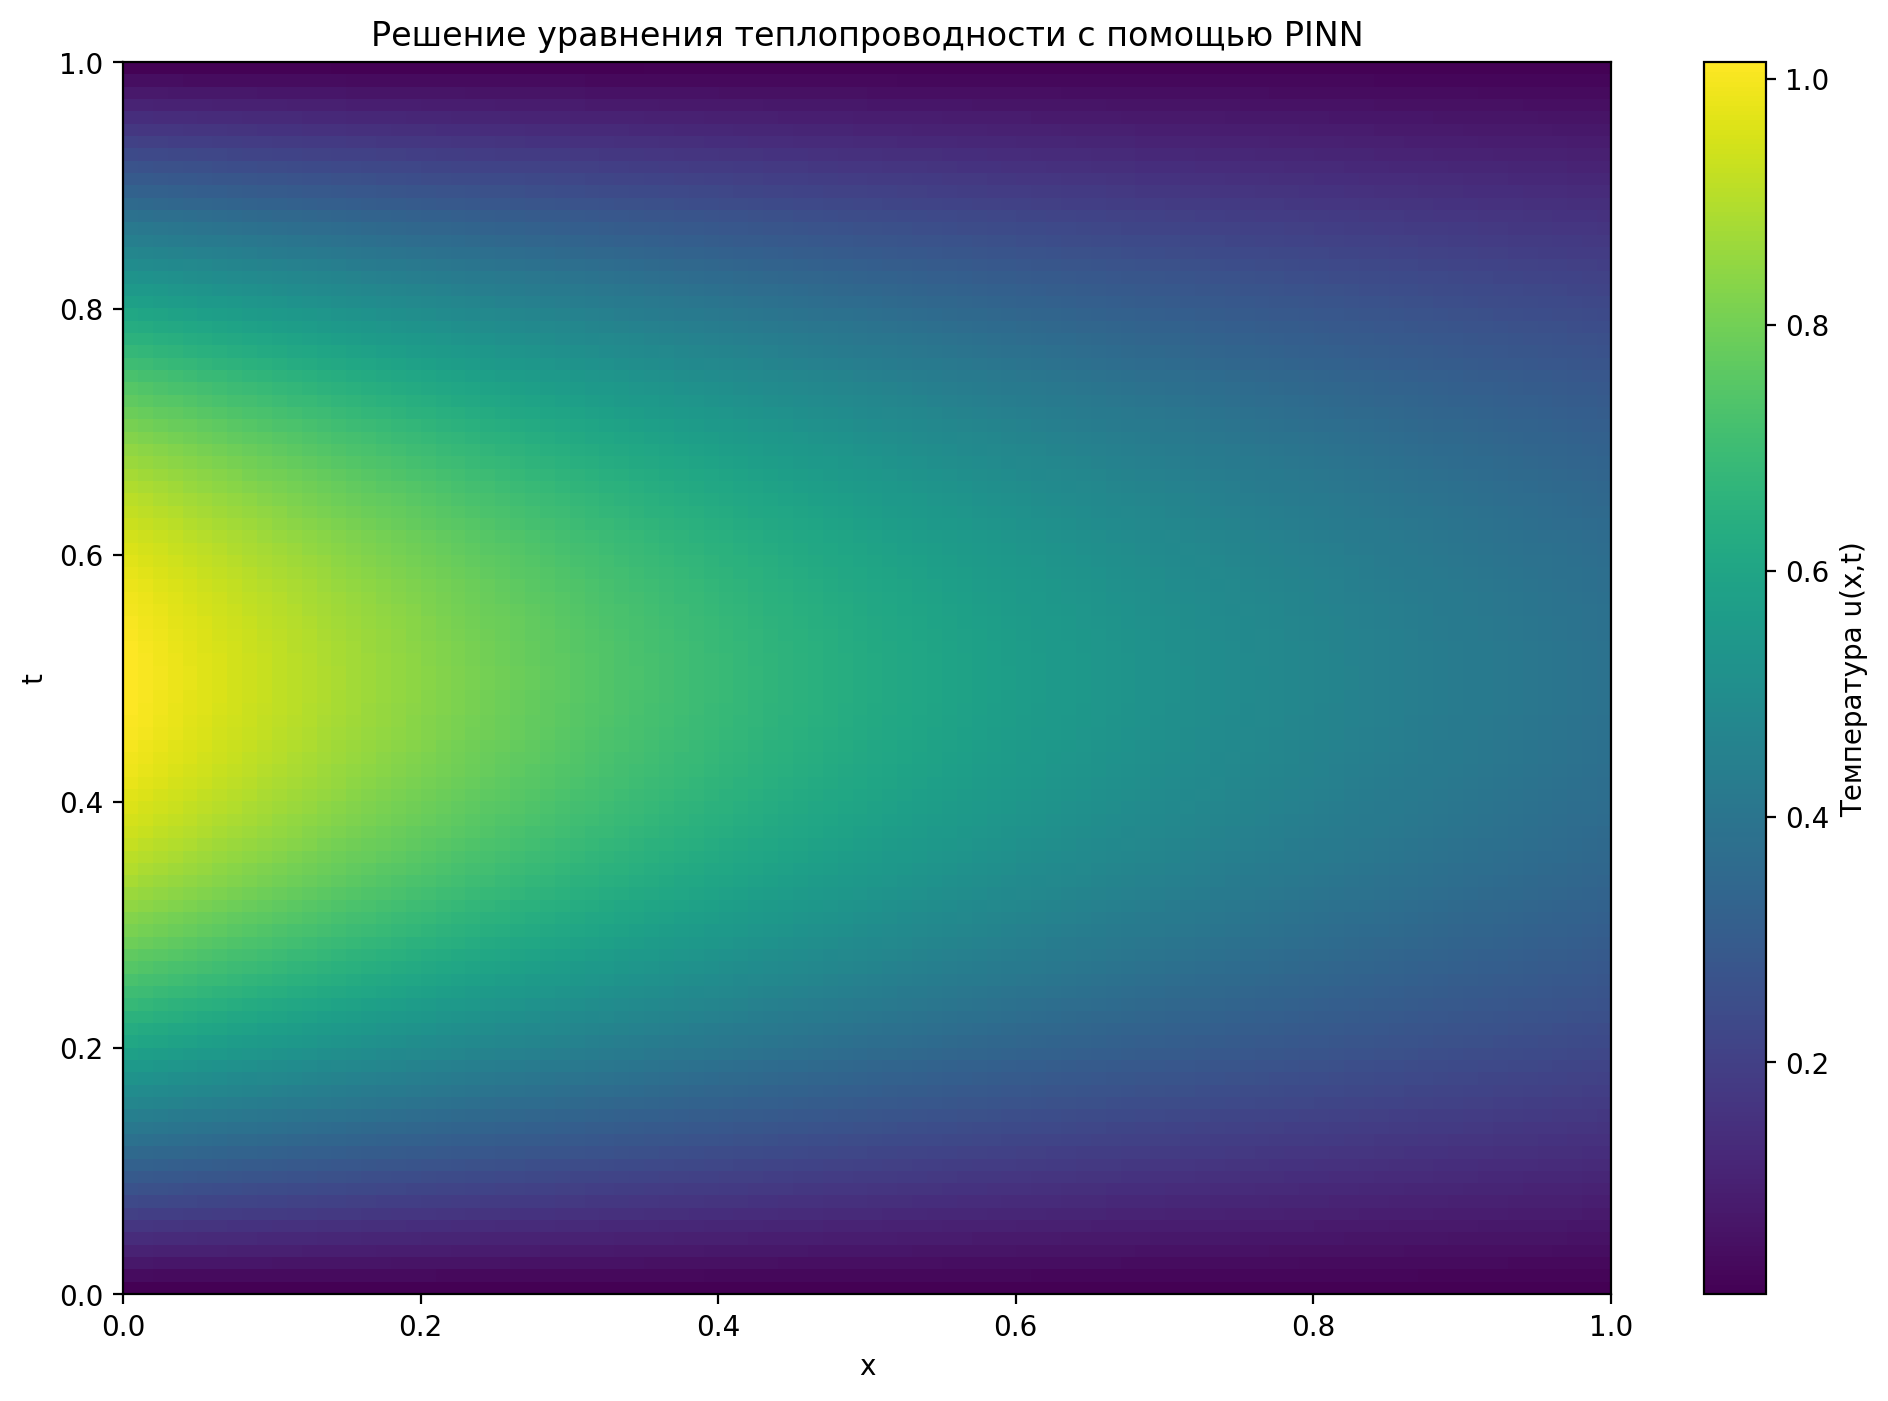

In [ ]:
# ----------------------------
# 6. Визуализация результатов
# ----------------------------

x = torch.linspace(0, 1, 100).view(-1, 1).to(device)
t = torch.linspace(0, 1, 100).view(-1, 1).to(device)
X, T = torch.meshgrid(x.squeeze(), t.squeeze(), indexing="ij")

# получаем предсказания u(x, t)
u_pred = model(X.reshape(-1, 1), T.reshape(-1, 1)).detach().cpu().numpy()
U = u_pred.reshape(100, 100)

# визуализация полученных результатов
plt.figure(figsize=(12, 8), dpi=200)
plt.imshow(U, extent=[0, 1, 0, 1], origin='lower', aspect='auto')
plt.colorbar(label="Температура u(x,t)")
plt.xlabel("x")
plt.ylabel("t")
plt.title("Решение уравнения теплопроводности с помощью PINN")
plt.show()

Получаем тепловую карту температуры во времени. График показывает плавное "затухание" синусоиды во времени - ровно как и должно быть в уравнении теплопроводности: температура выравнивается, пока система стремится к равновесию.

### Добавление анимации эволюции температуры

Добавление такой анимации позволит увидеть, как температура распределяется и выравнивается со временем.

После обучения PINN создадим анимацию эволюции $u(x, t) :$
* по оси $x$ - координата от 0 до 1,
* по оси $y$ - температура $u ,$
* по оси $t$ - будет идти анимация (время).

Это позволит увидеть, как синусоида (начальное состояние) **постепенно затухает к нулю** - решение уравнения теплопроводности.

In [ ]:
import matplotlib.animation as animation

In [ ]:
from IPython.display import HTML

In [ ]:
# ------------------------------
# 7. Получаем решение для сетки
# ------------------------------
x = torch.linspace(0, 1, 100).view(-1, 1).to(device)
t_vals = torch.linspace(0, 1, 100).to(device)

U = []
for t in t_vals:
    t_tensor = t.repeat(x.shape[0], 1)
    u_pred = model(x, t_tensor).detach().cpu().numpy().flatten()
    U.append(u_pred)

U = torch.tensor(U).T.numpy()  # форма (x, t)

/tmp/ipython-input-620573207.py:13: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  U = torch.tensor(U).T.numpy()  # форма (x, t)


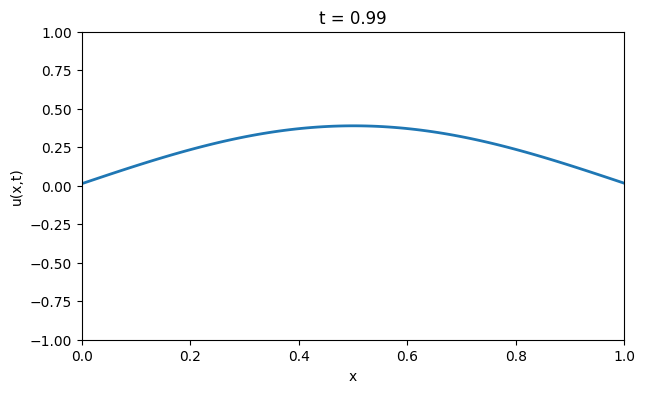

In [ ]:
# --------------------
# 8. Создаём анимацию
# --------------------
fig, ax = plt.subplots(figsize=(7, 4))
line, = ax.plot([], [], lw=2)
ax.set_xlim(0, 1)
ax.set_ylim(-1, 1)
ax.set_xlabel("x")
ax.set_ylabel("u(x,t)")
ax.set_title("Эволюция температуры во времени")

def init():
    line.set_data([], [])
    return line,

def update(frame):
    line.set_data(x.cpu().numpy(), U[:, frame])
    ax.set_title(f"t = {frame/100:.2f}")
    return line,

ani = animation.FuncAnimation(
    fig, update, frames=100, init_func=init, blit=True, interval=100
)

# Вариант 1 - работает только в Jupyter Notebook
# plt.show()

# Вариант 2 (для Colab) — встроить видео прямо в ноутбук
HTML(ani.to_html5_video())

# Вариант 3 — сохранить
# ani.save("pinn_diffusion.mp4", writer="ffmpeg", fps=20)

Мы видим, что на старте при $t=0$ график будет синусоидой $\sin(\pi x) .$ С течением времени амплитуда начнёт плавно спадать - это эффект теплопроводности: тепло распределяется, система выравнивается. К $t=1$ кривая почти "схлопнется" к нулю.

Это демонстрирует, что PINN не знает решения заранее - она просто учится так, чтобы её предсказания **соблюдали физическое уравнение и граничные условия**. Благодаря этому она может решать даже те уравнения, где аналитического решения нет, - без сетки и численных схем (типа конечных разностей).

### Добавим аналитическое решение для сравнения точности PINN

Сравнение с аналитическим решением - это полезный шаг, который позволяет убедиться в том, что PINN действительно *учится физике*, а не просто подгоняет данные.

Мы решаем уравнение теплопроводности:
$$\frac{\partial u}{\partial t} = \alpha \frac{\partial^2 u}{\partial x^2}$$

с начальными и граничными условиями:
$$u(x, 0) = \sin(\pi x), \: u(0, t) = 0, \: u(1, t) = 0$$

Для этого уравнения **точное алитическое решение** известно:
$$u(x, t) = e^{-\pi^2 \alpha t}\sin(\pi x) ,$$

где $\alpha$ - коэффициент теплопроводности (в коде = 0.1).

Необходимо добавить:
1. Расчёт аналитического решения
2. Визуальное сравнение (тепловые карты и графики ошибок)

In [ ]:
import numpy as np

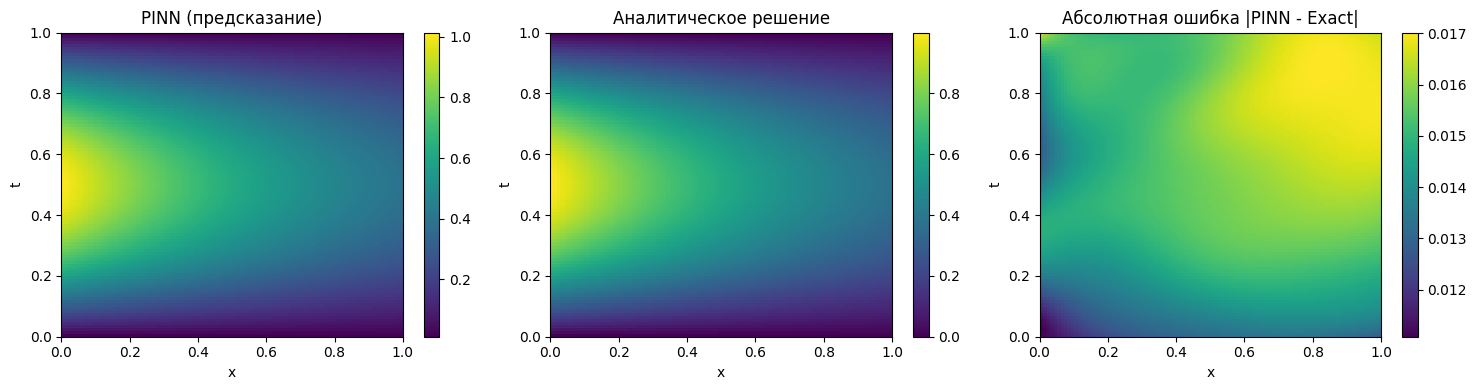

In [ ]:
# Предсказание PINN
U_pinn = []
for t in t_vals:
    t_tensor = t.repeat(x.shape[0], 1)
    u_pred = model(x, t_tensor).detach().cpu().numpy().flatten()
    U_pinn.append(u_pred)

U_pinn = np.array(U_pinn).T  # (x, t)

# -------------------------
# 9. Аналитическое решение
# -------------------------
alpha = 0.1
X, T = np.meshgrid(x.cpu().numpy().flatten(), t_vals.cpu().numpy().flatten(), indexing="ij")
U_exact = np.exp(-np.pi**2 * alpha * T) * np.sin(np.pi * X)

# -----------------------------------
# 10. Ошибка между PINN и аналитикой
# -----------------------------------
error = np.abs(U_pinn - U_exact)

# -----------------
# 11. Визуализация
# -----------------
fig, axs = plt.subplots(1, 3, figsize=(15, 4))

# PINN
im0 = axs[0].imshow(U_pinn, extent=[0,1,0,1], origin='lower', aspect='auto')
axs[0].set_title("PINN (предсказание)")
axs[0].set_xlabel("x")
axs[0].set_ylabel("t")
fig.colorbar(im0, ax=axs[0])

# Аналитическое решение
im1 = axs[1].imshow(U_exact, extent=[0,1,0,1], origin='lower', aspect='auto')
axs[1].set_title("Аналитическое решение")
axs[1].set_xlabel("x")
axs[1].set_ylabel("t")
fig.colorbar(im1, ax=axs[1])

# Ошибка
im2 = axs[2].imshow(error, extent=[0,1,0,1], origin='lower', aspect='auto')
axs[2].set_title("Абсолютная ошибка |PINN - Exact|")
axs[2].set_xlabel("x")
axs[2].set_ylabel("t")
fig.colorbar(im2, ax=axs[2])

plt.tight_layout()
plt.show()

Получаем следующие результаты:
1. Первая панель - предсказание PINN
2. Вторая - аналитическое решение
3. Третья - разница между ними (ошибка)

Также можно добавить численную оценку, например среднеквадратичную ошибку (MSE):

In [ ]:
mse = np.mean((U_pinn - U_exact)**2)
print(f"Среднеквадратичная ошибка PINN vs аналитическое решение: {mse}")

Среднеквадратичная ошибка PINN vs аналитическое решение: 0.0002337658661417663


---
# PINN в контексте ML TAVI
---

## ML в TAVI

TAVI (Transcatheter Aortic Valve Implantation) - малоинвазивная процедура замены аортального клапана, без открытой грудной операции. Чаще используется у пациентов с высоким риском традиционной операции. К основным проблемам / важным вопросам относятся: прогнозы на исходы (смертность, осложнения), подбор пациентов, оценка анатомии, прогноз после процедуры и др.

На данный момент ML уже применяется в TAVI для решения следующих проблем:
* Предсказания смертности (30 дней, 1 год, 5 лет) после TAVI -> [статья](https://pubmed.ncbi.nlm.nih.gov/33923465/).
* Предсказания осложнений, например, необходимость установки постоянного электрокардиостимулятора после процедуры -> [статья](https://pubmed.ncbi.nlm.nih.gov/39443560/).
* Разного рода risk-scores, оценки ожидаемого улучшения симптомов, качества жизни и др. -> [статья](https://mijn.bsl.nl/value-of-machine-learning-in-predicting-tavi-outcomes/16737098?utm_source=chatgpt.com)

## Почему PINN может быть интересен в контексте TAVI

PINN обычно применяются, когда процессы можно описать физическими уравнениями, дифференциальными уравнениями, законами течения, биомеханики и т.п. В TAVI существуют подзадачи, где физика и биомеханика важны, например:
1. **Кровоток через новую клапанную систему** - гидродинамика, давления, скорость крови, потери жидкости, градиенты давления.
2. **Механика клапана / движения листков** - как будут деформироваться ткани, как листки клапана открываются / закрываются, есть ли остаточные протечки (paravalvular leak).
3. **Изменения в сердце до и после нагрузки** - как нагрузка изменяется, как стенки желудочка реагируют, как изменяется трение крови и др.
4. **Потери энергии, турбулентность, швы** - важна оценка, особенно при сложной анатомии или патологии сосудов.

Если можно описать такие процессы через PDE / физические модели, то PINN может помочь:
* Улучшить прогноз, учитывая физические законы, а не только статистику.
* Быстро моделировать, без полной CFD-симуляции, которая может быть тяжёлой и медленной.
* Учитывая вариации анатомии у пациента - например, геометрия аорты, размеры клапанов, динамика сократимости сердечной мышцы и др.

## Некоторые возможные сценарии применения PINN в TAVI

**Пример А. Моделирование градиента давления через протез клапана**

**Задача:** Необходимо предсказать, как будет изменяться градиент давления через новый клапан (или между клапаном и стенками) у данного пациента, с учётом анатомии (геометрии сосуда, аорты), кровотока, вязкости крови и др.

**Физическая модель:** можно использовать уравнение Навье-Стокса (или упрощённые модели потока крови), законы сохранения массы и импульса, возможно учесть трение стенок, форму клапана, деформации листков.

**Реализация  PINN:**
* Вход: геометрия пациента (например, профили сосудов / размеров, формы), параметры крови, параметры клапана, дебит (объёмный поток, скорость), возможно давление до клапана.
* Сеть выдаёт давление в разных точках, скорость потока, градиент давления.
* Loss-часть: условие, что решения сети должны удовлетворять физическим уравнениям (например, уравнениям потока) + возможно граничные условия (например, давление на входе, давление на выходе, нет сквозных утечек) + данные измерений, если есть (например, от УЗИ, катетеризации), для справки.

**Преимущества:** быстрее, чем полная CFD + возможность адаптироваться к конкретному пациенту.

**Пример Б. Оценка риска осложнений на основе биомеханики**

**Задача:** предсказать, будет ли после TAVI значительный paravalvular leak (утечка вокруг клапана), исходя из формы анатомии, позиции имплантированного клапана, давления и динамики движения листков.

**Физическая модель:** возможно упрощённая модель с упругими стенками, воздействием клапана / тканей, текучести крови, давления.

**Реализация PINN:** сеть, которая моделирует утечку, используя физические граничные условия и данные (из КТ, эхокардиографии), чтобы предсказать утечку и её степень.

**Пример В. Обратная задача: оценка свойств тканей / клапана по данным**

**Задача:** измерены данные (эхокардиография, поток, давление) до / после TAVI, но не точно известна жёсткость ткани, сопротивление потоку, или другие параметры, которые влияют на исход. Можно "обратной" моделью (PINN) оценить эти скрытые параметры.

**Физическая модель + обратная задача:** сеть обучается, чтобы её предсказания соответствовали и физическим законам и измерениям, и выявить параметры, которые объясняют разницу.

## Сложности и ограничения

1. Требуются **хорошо развитые физические модели:** надо понимать, какие уравнения подходят, какие упрощения допустими.
2. Данные с высокой детализацией: хорошо бы иметь геометрию сосудов, клапанов (3D), измерения скорости, давления и др. Часто таких данных или нет, или они шумны.
3. Обработка 3D-геометрии и сложной анатомии - вычислительно тяжёлая задача.
4. Баланс между "физика loss" и "data loss" может быть сложным: если физических ограничений слишком много / они жёсткие, сеть может плохо подгонять реальные данные; если они слишком мягкие - сеть может отклониться от физически реального.
5. Верификация: нужно сравнивать предсказания с результатами наблюдений / экспериментов.

## Некоторые шаги по применению PINN к TAVI

1. Постановка задачи - например, предсказание градиента давления через клапан, предскзание утечки или риска осложнений.
2. Собрать данные:
    * Данные пациента (КТ, МРТ)
    * Измерения потока крови, давления
    * Информация о параметрах клапана, свойствах тканей
3. Выбрать физическую модель: сделать прототип можели, какое уравнение будет использоваться (например, урезанный поток в трубе, или упрощённая модель стенок + клапан)
4. Построить PINN:
    * Определить, что будет входом, что -выходом
    * Определить loss-функцию: data loss + physics loss + граничные условия
    * Настроить архитектуру
5. Тестировать / валидировать: сравнить с измерениями, возможно с CFD или с результатами операционных или послеоперационных обследований.
6. Интерпретировать: важно, чтобы результаты имели клинический смысл, и убедиться, что сеть не выучила "шаблоны" данных, а получила действительно физически обоснованные связи.

---
# PINN для моделирования потока крови через аортальный клапан после TAVI

---

**Цель:** предсказать **падение давления** (pressure gradient) через имплантированный клапан в зависимости от скорости кровотока, радиуса клапана и вязкости крови.

От этого физиологического параметра зависит нагрузка на сердце и успех имплантации.

**Математическая модель:** для начала возьмём 1D-упрощённую версию уравнения Навье-Стокса (ламинарный поток в сосуде — это слоистое течение крови, без завихрений и перемешивания слоёв):

$$\rho \frac{\partial u}{\partial t} + \rho u\frac{\partial u}{\partial x} = -\frac{\partial p}{\partial x} + \mu \frac{\partial^2 u}{\partial x^2} ,$$

где:
* $u(x, t)$ - скорость крови,
* $p(x, t)$ - давление,
* $\rho$ - плотность крови,
* $\mu$ - вязкость крови.

Для простоты будем считать $\rho=1, \ \mu=0.01$ и рассматриваем короткий участок сосуда ($x \in [0, 1]$).

**Что делает PINN:**
1. Нейросеть принимает $x, t$ и предсказывает $u(x, t)$ и $p(x, t) .$
2. Через автодифференцирование вычисляем производные и подставляем их в уравнение Навье-Стокса.
3. Обучаем сеть, чтобы она **соблюдала физику потока + соответствовала граничным данным.**

In [ ]:
# ----------------------------------
# 1. Параметры "крови" и устройства
# ----------------------------------

rho = 1.0    # плотность
mu = 0.01    # вязкость
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# ------------------------------------------------
# 2. Модель PINN: предсказывает u(x, t) и p(x, t)
# ------------------------------------------------

class PINN_TAVI(nn.Module):

    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64),
            nn.Tanh(),
            nn.Linear(64, 64),
            nn.Tanh(),
            nn.Linear(64, 2)   # выход: [u, p]
        )

    def forward(self, x, t):
        inputs = torch.cat([x, t], dim=1)
        out = self.net(inputs)
        u = out[:, [0]]
        p = out[:, [1]]

        return u, p

# ------------------------------------
# 3. Функция для производных и потерь
# ------------------------------------

def navier_stokes_loss(model, x, t):
    """Возвращает loss, исходя из уравнения Навье–Стокса"""

    u, p = model(x, t)

    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    p_x = torch.autograd.grad(p, x, torch.ones_like(p), create_graph=True)[0]

    # Уравнение Навье–Стокса: ρ(u_t + u u_x) = -p_x + μ u_xx
    eq = rho * (u_t + u * u_x) + p_x - mu * u_xx
    physics_loss = (eq ** 2).mean()

    return physics_loss

In [ ]:
# ------------
# 4. Обучение
# ------------

lambda_phys = 0.5  # вес для физического loss
model = PINN_TAVI().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

for epoch in range(8000):

    # точки для физического loss
    x = torch.rand(2000, 1, requires_grad=True).to(device)
    t = torch.rand(2000, 1, requires_grad=True).to(device)
    loss_phys = navier_stokes_loss(model, x, t)

    # === Граничные условия ===
    # входная скорость: всегда положительная (пульсирующий поток)
    u_in_target = 0.5 * (1.0 + torch.sin(2 * torch.pi * t))
    u_in_pred, p_in_pred = model(torch.zeros_like(t), t)
    loss_in_u = ((u_in_pred - u_in_target) ** 2).mean()
    loss_in_p = ((p_in_pred - 1.0) ** 2).mean()   # давление на входе = 1

    # выход: фиксируем давление и малую скорость
    u_out_pred, p_out_pred = model(torch.ones_like(t), t)
    loss_out_u = ((u_out_pred - 0.1) ** 2).mean()
    loss_out_p = (p_out_pred ** 2).mean()         # давление на выходе = 0

    # общий loss
    loss_bc = loss_in_u + loss_in_p + loss_out_u + loss_out_p
    loss = loss_bc + lambda_phys * loss_phys

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # лог
    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | Total Loss={loss.item():.6f} | Phys={loss_phys.item():.6e}")


Epoch     0 | Total Loss=1.584226 | Phys=4.138054e-02
Epoch   500 | Total Loss=0.042327 | Phys=2.217343e-02
Epoch  1000 | Total Loss=0.007068 | Phys=3.691253e-03
Epoch  1500 | Total Loss=0.002983 | Phys=2.584585e-03
Epoch  2000 | Total Loss=0.001780 | Phys=1.808240e-03
Epoch  2500 | Total Loss=0.001299 | Phys=1.487061e-03
Epoch  3000 | Total Loss=0.000978 | Phys=1.142931e-03
Epoch  3500 | Total Loss=0.000648 | Phys=7.544071e-04
Epoch  4000 | Total Loss=0.000602 | Phys=7.166002e-04
Epoch  4500 | Total Loss=0.000520 | Phys=6.988082e-04
Epoch  5000 | Total Loss=0.000428 | Phys=5.731618e-04
Epoch  5500 | Total Loss=0.000291 | Phys=4.008471e-04
Epoch  6000 | Total Loss=0.000262 | Phys=3.586310e-04
Epoch  6500 | Total Loss=0.000233 | Phys=3.317983e-04
Epoch  7000 | Total Loss=0.000179 | Phys=2.586408e-04
Epoch  7500 | Total Loss=0.000277 | Phys=3.977457e-04


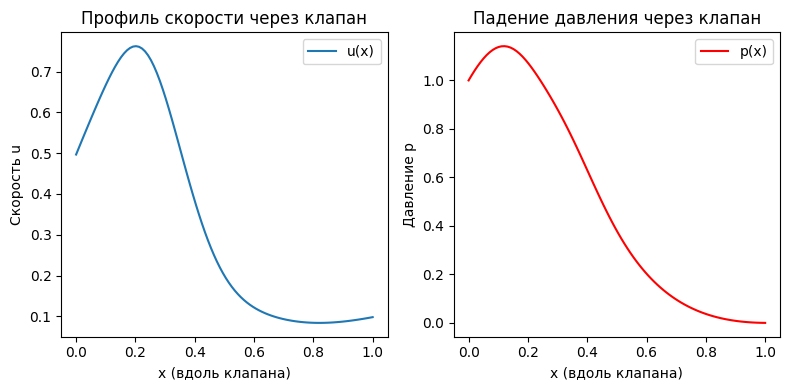

In [ ]:
# ----------------
# 5. Визуализация
# ----------------

x_grid = torch.linspace(0, 1, 100).view(-1, 1).to(device)
t_const = torch.tensor([[0.5]]).repeat(100, 1).to(device)   # середина цикла
u_pred, p_pred = model(x_grid, t_const)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(x_grid.cpu(), u_pred.detach().cpu(), label='u(x)')
plt.xlabel("x (вдоль клапана)")
plt.ylabel("Скорость u")
plt.title("Профиль скорости через клапан")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x_grid.cpu(), p_pred.detach().cpu(), label='p(x)', color='red')
plt.xlabel("x (вдоль клапана)")
plt.ylabel("Давление p")
plt.title("Падение давления через клапан")
plt.legend()
plt.tight_layout()
plt.show()

**Вывод по полученным графикам:**

1. Профиль скорости через клапан ($u(x)$)

    На первом графике видна характерная форма, типичная для потока через сужение (например, при протезировании аортального клапана - TAVI):

    * В начале участка ($x \approx 0$) скорость **невысокая**, потому что поток ещё не ускорился.
    * В районе $x \approx 0.2-0.3$ наблюдается **максимум скорости** - кровь проходит через **зону наибольшего сужения** (эффект Вентури).
    * После этого скорость плавно **уменьшается**, что говорит о **расширении просвета** и частичном восстановлении давления.

    Это можно интерпретировать следующим образом: модель PINN корректно воспроизвела ускорение потока при прохождении через клапан и замедление после него, что соответствует физиологическому поведению кровотока при TAVI и подтверждает, что нейросеть усвоила физические зависимости из уравнения Навье-Стокса.

2. Падение давления через клапан ($p(x)$)

    Второй график показывает монотонное снижение давления вдоль оси x:

    * Входное давление ($x = 0$) около 1.0 - это условное "аортальное" давление до клапана.
    * К выходу ($x = 1$) давление стремится к 0 - что отражает **гидродинамическое сопротивление** клапана.

    Это можно интепретировать следующим образом: монотонное убывание давления без колебаний - это **признак устойчивого ламинарного течения**. Плавный градиент давления поддерживает ускорения потока, которое видно на первом графике.

3. Физическая согласованность

    Между графиками $u(x)$ и $p(x)$ наблюдается обратная зависимость:

    * Там, где скорость возрастает - давление падает быстрее;
    * Где скорость падает - давление выравнивается.

    В целом, это согласуется с уравнением Навье-Стокса, т.е. можно сделать вывод - что нейросеть действительно усвоила физику процесса, а не просто подогнала данные.

## Добавление вспомогательных графиков и анимации

Добавим в код ещё два блока:

1. **Мониторинг residual** - чтобы видеть, насколько точно PINN соблюдает уравнение Навье-Стокса.
2. Визуализацию поля $u(x, t)$ - динамическое изменение скорости по времени.

Также внесём некоторые необходимые изменения в некоторых частях кода.

In [ ]:
# ------------------------------------
# 3.1. Функция потерь (Навье–Стокса)
# ------------------------------------
def navier_stokes_loss(model, x, t):
    """Возвращает физический loss и невязку (residual)"""
    u, p = model(x, t)

    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]
    p_x = torch.autograd.grad(p, x, torch.ones_like(p), create_graph=True)[0]

    eq = rho * (u_t + u * u_x) + p_x - mu * u_xx
    physics_loss = (eq ** 2).mean()
    return physics_loss, eq.detach()

In [ ]:
# -----------------
# 4.1. Обучение PINN
# -----------------
lambda_phys = 0.5
model = PINN_TAVI().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

residual_history = []

for epoch in range(8000):
    # точки для физического loss
    x = torch.rand(2000, 1, requires_grad=True).to(device)
    t = torch.rand(2000, 1, requires_grad=True).to(device)
    loss_phys, eq_vals = navier_stokes_loss(model, x, t)

    # === Граничные условия ===
    # Входная скорость: положительная синусоида
    u_in_target = 0.5 * (1.0 + torch.sin(2 * torch.pi * t))
    u_in_pred, p_in_pred = model(torch.zeros_like(t), t)
    loss_in_u = ((u_in_pred - u_in_target) ** 2).mean()
    loss_in_p = ((p_in_pred - 1.0) ** 2).mean()   # давление на входе = 1

    # Выход: фиксируем давление = 0 и малую скорость
    u_out_pred, p_out_pred = model(torch.ones_like(t), t)
    loss_out_u = ((u_out_pred - 0.1) ** 2).mean()
    loss_out_p = (p_out_pred ** 2).mean()

    # Общий loss
    loss_bc = loss_in_u + loss_in_p + loss_out_u + loss_out_p
    loss = loss_bc + lambda_phys * loss_phys

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    residual_history.append(loss_phys.item())

    if epoch % 500 == 0:
        print(f"Epoch {epoch:5d} | Total={loss.item():.6f} | Phys={loss_phys.item():.6e} | BC={loss_bc.item():.6f}")

Epoch     0 | Total=1.356636 | Phys=1.673643e-03 | BC=1.355799
Epoch   500 | Total=0.046445 | Phys=3.709818e-02 | BC=0.027896
Epoch  1000 | Total=0.009836 | Phys=8.418075e-03 | BC=0.005627
Epoch  1500 | Total=0.003768 | Phys=3.897496e-03 | BC=0.001820
Epoch  2000 | Total=0.002054 | Phys=2.244630e-03 | BC=0.000932
Epoch  2500 | Total=0.001095 | Phys=1.151924e-03 | BC=0.000519
Epoch  3000 | Total=0.000839 | Phys=9.162403e-04 | BC=0.000381
Epoch  3500 | Total=0.000829 | Phys=1.043607e-03 | BC=0.000307
Epoch  4000 | Total=0.000547 | Phys=6.857319e-04 | BC=0.000204
Epoch  4500 | Total=0.000444 | Phys=5.568129e-04 | BC=0.000165
Epoch  5000 | Total=0.000392 | Phys=5.085421e-04 | BC=0.000138
Epoch  5500 | Total=0.000337 | Phys=4.573282e-04 | BC=0.000108
Epoch  6000 | Total=0.000428 | Phys=5.195504e-04 | BC=0.000168
Epoch  6500 | Total=0.000560 | Phys=6.542712e-04 | BC=0.000233
Epoch  7000 | Total=0.000224 | Phys=3.125504e-04 | BC=0.000068
Epoch  7500 | Total=0.000188 | Phys=2.536925e-04 | BC=0

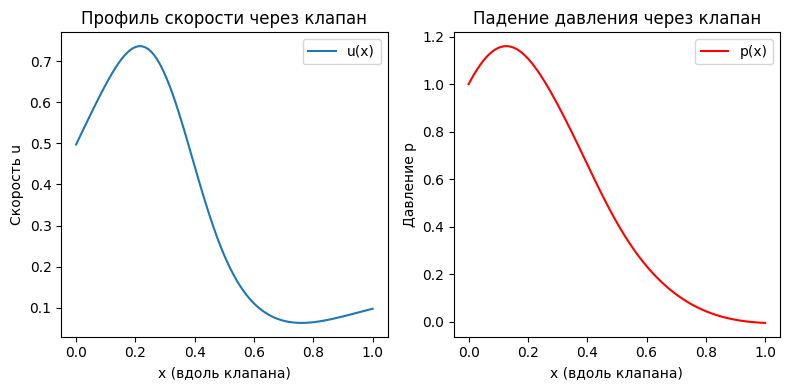

In [ ]:
# ----------------
# 5.1. Визуализация
# ----------------

x_grid = torch.linspace(0, 1, 100).view(-1, 1).to(device)
t_const = torch.tensor([[0.5]]).repeat(100, 1).to(device)   # середина цикла
u_pred, p_pred = model(x_grid, t_const)

plt.figure(figsize=(8, 4))
plt.subplot(1, 2, 1)
plt.plot(x_grid.cpu(), u_pred.detach().cpu(), label='u(x)')
plt.xlabel("x (вдоль клапана)")
plt.ylabel("Скорость u")
plt.title("Профиль скорости через клапан")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(x_grid.cpu(), p_pred.detach().cpu(), label='p(x)', color='red')
plt.xlabel("x (вдоль клапана)")
plt.ylabel("Давление p")
plt.title("Падение давления через клапан")
plt.legend()
plt.tight_layout()
plt.show()

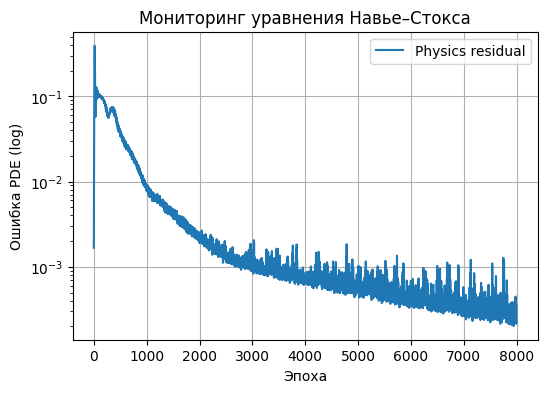

In [ ]:
# -----------------------------
# 6.1. Мониторинг residual (PDE)
# -----------------------------
plt.figure(figsize=(6,4))
plt.plot(residual_history, label='Physics residual')
plt.yscale('log')
plt.xlabel("Эпоха")
plt.ylabel("Ошибка PDE (log)")
plt.title("Мониторинг уравнения Навье–Стокса")
plt.legend()
plt.grid(True)
plt.show()

**Анализ полученного графика:**

1. **Общая динамика**

На графике видно:
    
* В начале(0-500 эпох) - высокий residual $\approx 10^{-1} - 10^{-2} .$ Это нормально: модель только начинает обучаться и случайно нарушает уравнение Навье-Стокса.
* С 1000 до 4000 эпох - наблюдается **плавное убывание ошибки,** что говорит о том, что сеть адаптируется к физическим ограничениям.
* После 5000 эпох - residual стабилизируется в диапазоне $10^{-3}-10^{-4},$ иногда с мелкими осцилляциями.

Это можно назвать хорошим результатом - ошибка PDE на уровне $10^{-3}$ - физически мелкими осцилляциями.

2. **Колебания после сходимости**

Пилообразный вид графика объясняется следующими условиями:

* стохастическим характером сэмплирования (`torch.rand` генерирует новые точки каждый шаг);
* влиянием граничных условий (особенно пульсирующего потока).

Если бы residual начал расти после 6000 эпох, это был бы признак переобучения, но здесь он остаётся стабильным - значит, модель удерживает баланс между PDE и граничными условиями.

3. Физическая интерпретация:

* PINN нашла **устойчиваое решение** уравнения Навье-Стокса для заданных параметров ($\rho, \mu$).
* Она **соблюдает физику** (закон сохранения импульса, баланс давления и вязкости).
* Текущее состояние можно считать **стадией сходимости** - сеть больше не нарушает физические законы.

4. Вывод:

Можно сказать, что модель успешно обучилась и минимизировала физический residual до стабильного уровня, также она не переобучилась (нет роста ошибки на поздних этапах) и соответствует физическому поведению потока крови через клапан.

In [ ]:
from matplotlib.animation import FuncAnimation

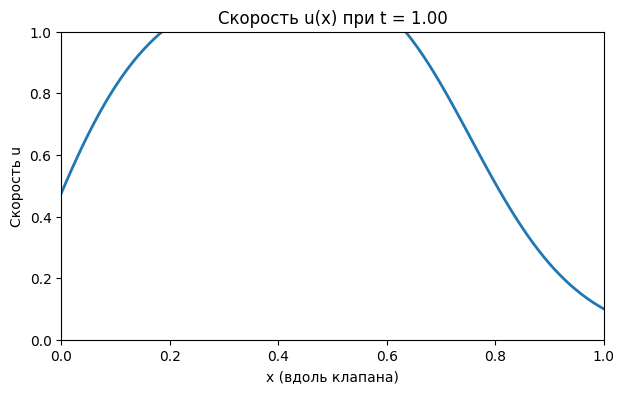

In [ ]:
# -----------------------------
# 7.1. Анимация u(x, t)
# -----------------------------
x_grid = torch.linspace(0, 1, 100).view(-1, 1).to(device)
t_values = torch.linspace(0, 1, 60).to(device)  # 60 кадров

u_field = []
for t_val in t_values:
    t_batch = torch.full_like(x_grid, t_val)
    u_pred, _ = model(x_grid, t_batch)
    u_field.append(u_pred.detach().cpu().numpy())

u_field = np.array(u_field).squeeze().T  # [x, t]

# Создаём анимацию изменения скорости
fig, ax = plt.subplots(figsize=(7,4))
line, = ax.plot([], [], lw=2)
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xlabel("x (вдоль клапана)")
ax.set_ylabel("Скорость u")
ax.set_title("Изменение скорости u(x, t) во времени")

def init():
    line.set_data([], [])
    return line,

def animate(i):
    line.set_data(x_grid.cpu().numpy(), u_field[:, i])
    ax.set_title(f"Скорость u(x) при t = {t_values[i]:.2f}")
    return line,

anim = FuncAnimation(fig, animate, init_func=init,
                     frames=len(t_values), interval=100, blit=True)

HTML(anim.to_html5_video())
